# 🚗 CarDekho — Exploratory Data Analysis

End-to-end EDA for the car price prediction project.  
Dataset: `data/cardekho.csv` — 8,128 used-car listings scraped from CarDekho.

**Contents**
1. Load & inspect
2. Missing values
3. Target distribution (selling price)
4. Categorical feature distributions
5. Numerical feature distributions
6. Correlation heatmap
7. Price vs key features
8. Outlier analysis
9. Key findings summary

In [1]:
import sys
sys.path.insert(0, '..')   # allow importing src/ from notebooks/

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# consistent style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = '../data/cardekho.csv'

---
## 1. Load & Inspect

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (8128, 12)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [3]:
df_raw.dtypes

name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
dtype: object

In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage(km/ltr/kg),7907.0,NaN,NaN,NaN,19.418783,4.037145,0.0,16.78,19.3,22.32,42.0
engine,7907.0,NaN,NaN,NaN,1458.625016,503.916303,624.0,1197.0,1248.0,1582.0,3604.0


---
## 2. Missing Values

                    count   pct
mileage(km/ltr/kg)    221  2.72
engine                221  2.72
seats                 221  2.72
max_power             215  2.65


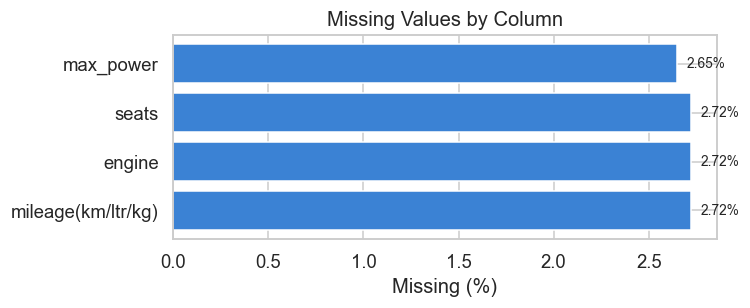

In [5]:
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]
print(missing_df)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(missing_df.index, missing_df['pct'], color='#3b82d4')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
for i, v in enumerate(missing_df['pct']):
    ax.text(v + 0.05, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Target Distribution — Selling Price

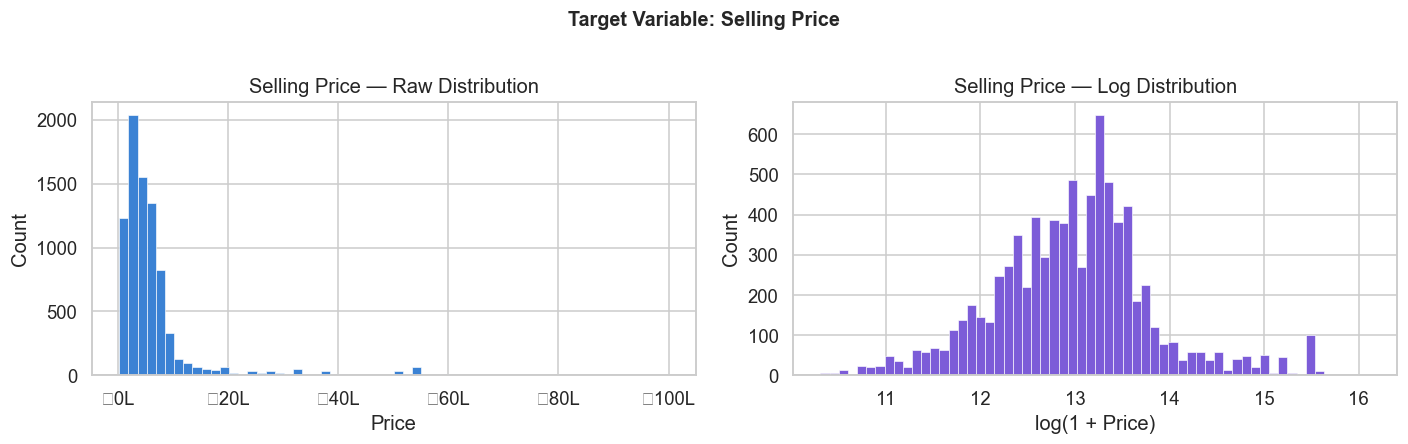

Mean:   ₹     638,272
Median: ₹     450,000
Std:    ₹     806,253
Min:    ₹      29,999
Max:    ₹  10,000,000


In [6]:
price = df_raw['selling_price'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw price
axes[0].hist(price, bins=60, color='#3b82d4', edgecolor='white', linewidth=0.4)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].set_title('Selling Price — Raw Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# Log-transformed price
axes[1].hist(np.log1p(price), bins=60, color='#7c5cd8', edgecolor='white', linewidth=0.4)
axes[1].set_title('Selling Price — Log Distribution')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: Selling Price', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean:   ₹{price.mean():>12,.0f}')
print(f'Median: ₹{price.median():>12,.0f}')
print(f'Std:    ₹{price.std():>12,.0f}')
print(f'Min:    ₹{price.min():>12,.0f}')
print(f'Max:    ₹{price.max():>12,.0f}')

---
## 4. Categorical Feature Distributions

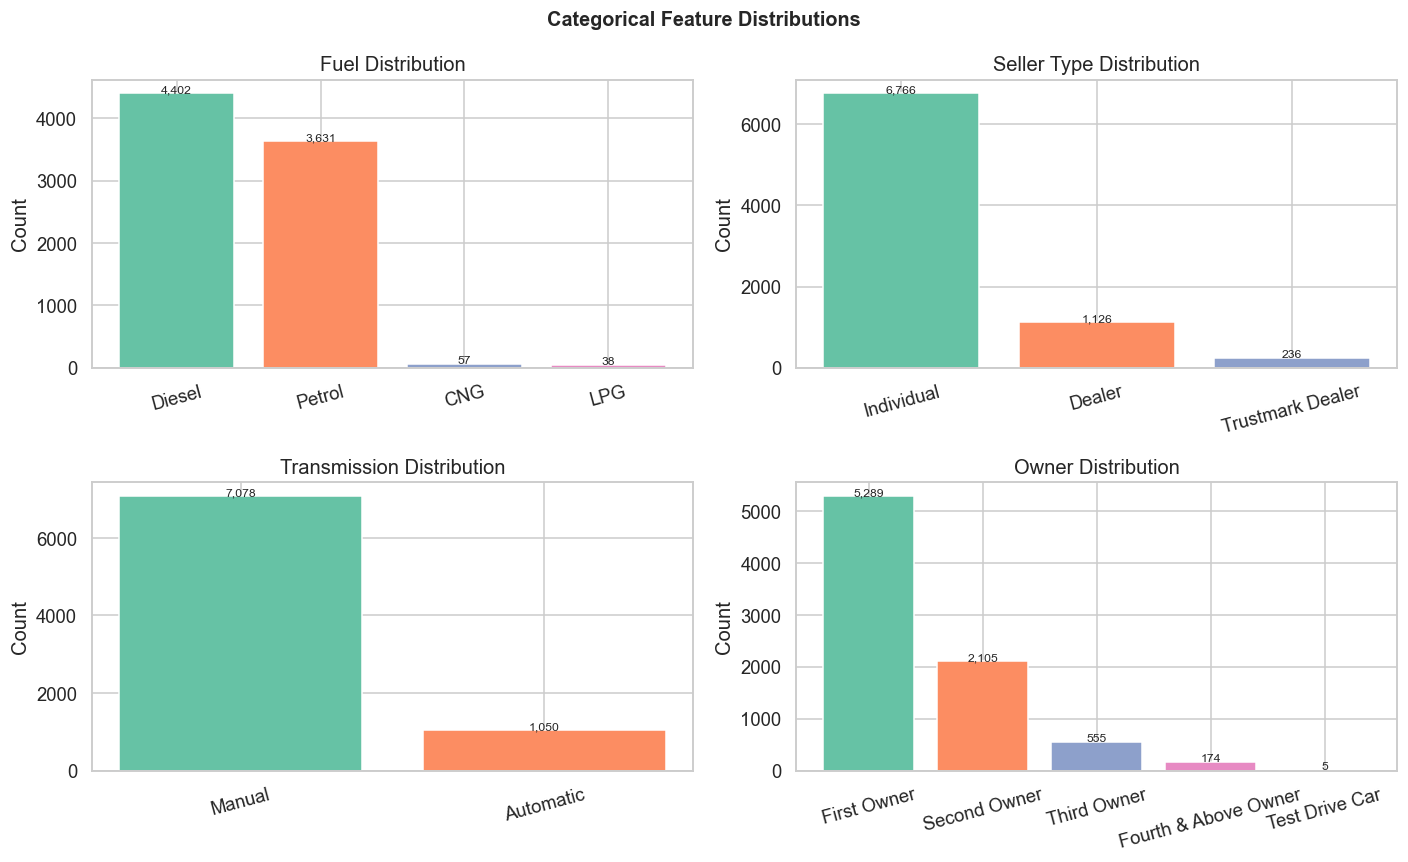

In [7]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df_raw[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=sns.color_palette('Set2', len(vc)))
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)
    for j, (x, v) in enumerate(zip(vc.index, vc.values)):
        axes[i].text(j, v + 10, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

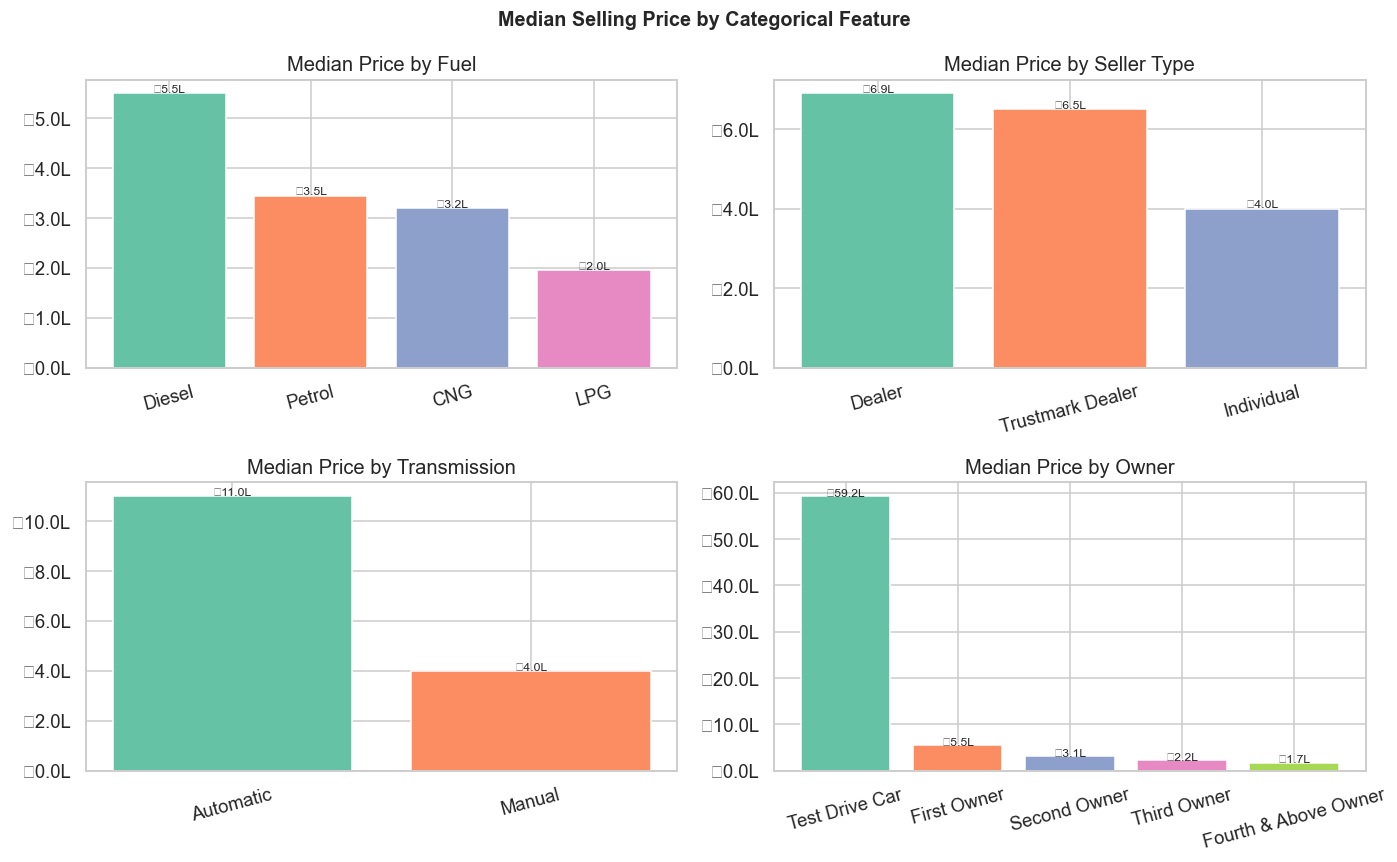

In [8]:
# Median price by each categorical feature
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    grp = df_raw.groupby(col)['selling_price'].median().sort_values(ascending=False)
    colors = sns.color_palette('Set2', len(grp))
    bars = axes[i].bar(grp.index, grp.values, color=colors)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L'))
    axes[i].set_title(f'Median Price by {col.replace("_", " ").title()}')
    axes[i].tick_params(axis='x', rotation=15)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                     f'₹{bar.get_height()/1e5:.1f}L', ha='center', fontsize=8)

plt.suptitle('Median Selling Price by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Numerical Feature Distributions

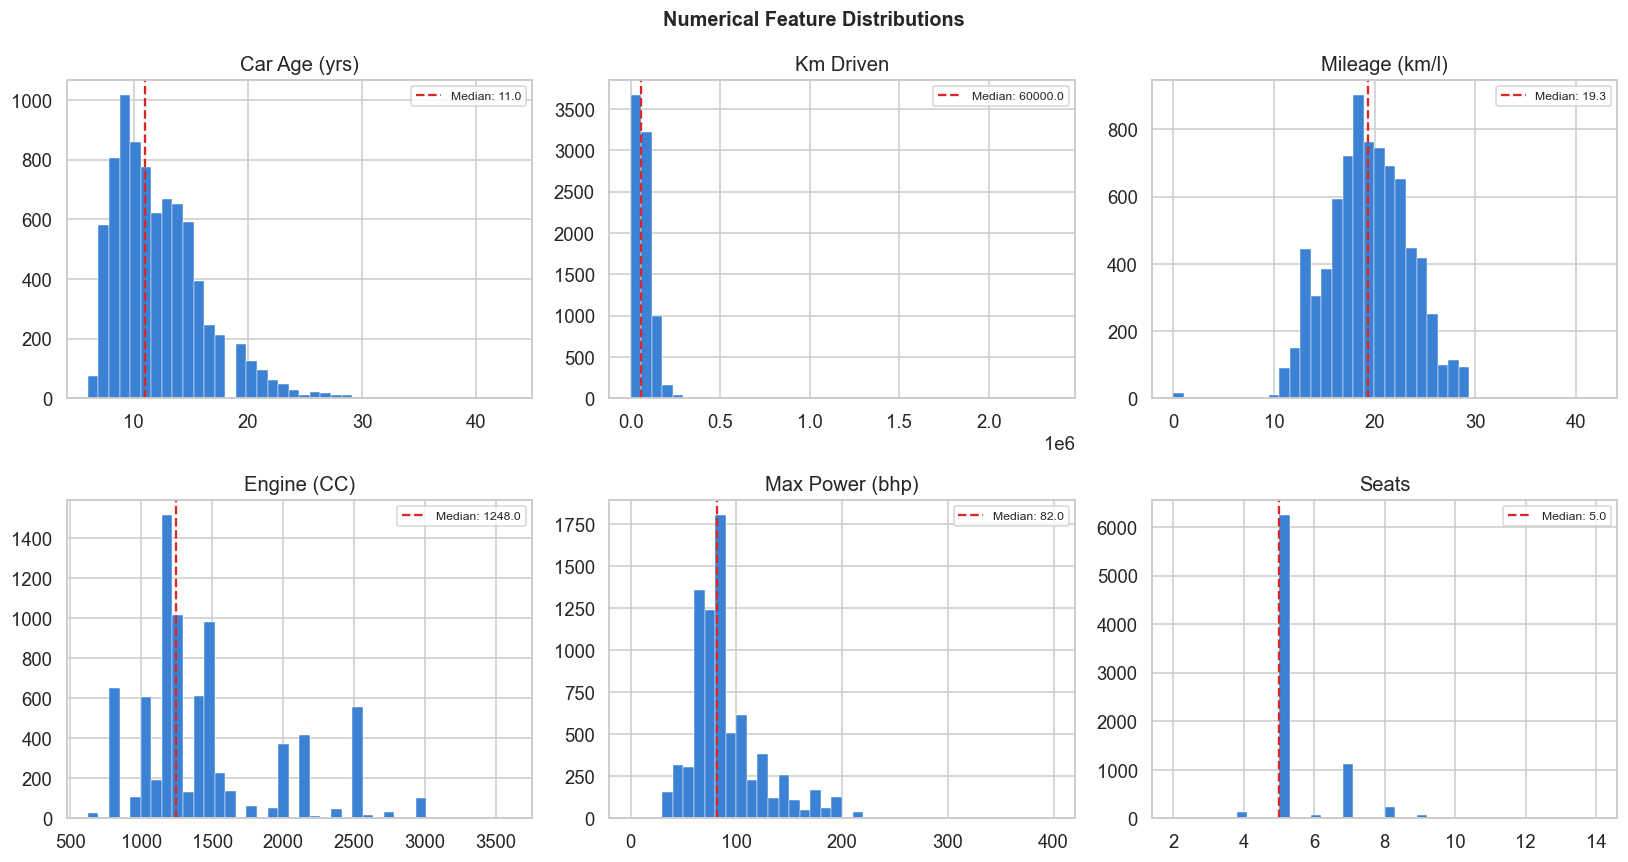

In [9]:
# Derive car_age for analysis
import datetime
df = df_raw.copy()
df['car_age'] = datetime.datetime.now().year - df['year']
df['max_power_num'] = pd.to_numeric(df['max_power'].replace('', np.nan), errors='coerce')
df = df.rename(columns={'mileage(km/ltr/kg)': 'mileage'})

num_cols = ['car_age', 'km_driven', 'mileage', 'engine', 'max_power_num', 'seats']
labels   = ['Car Age (yrs)', 'Km Driven', 'Mileage (km/l)', 'Engine (CC)', 'Max Power (bhp)', 'Seats']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(num_cols, labels)):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#3b82d4', edgecolor='white', linewidth=0.3)
    axes[i].axvline(data.median(), color='#dc2626', linewidth=1.5, linestyle='--', label=f'Median: {data.median():.1f}')
    axes[i].set_title(lbl)
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Correlation Heatmap

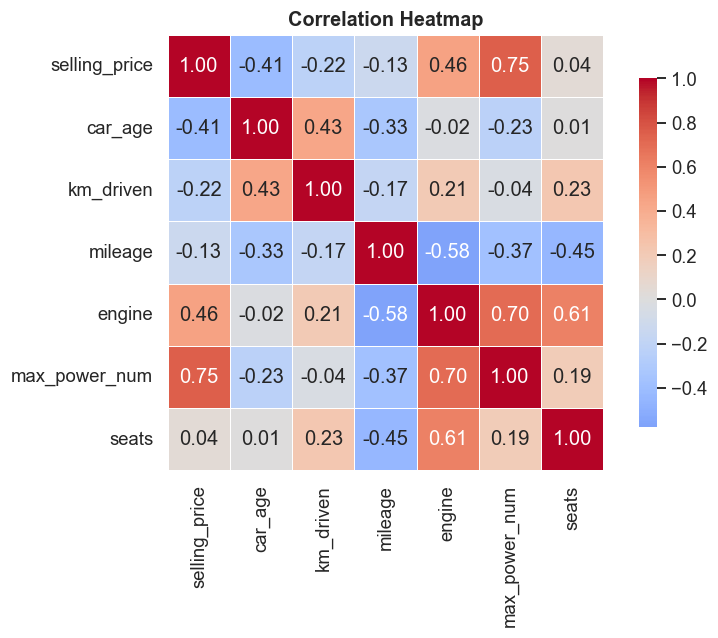


Correlation with selling_price:
max_power_num    0.749674
engine           0.455682
seats            0.041617
mileage         -0.126280
km_driven       -0.222158
car_age         -0.412302


In [10]:
corr_cols = ['selling_price', 'car_age', 'km_driven', 'mileage', 'engine', 'max_power_num', 'seats']
corr_df = df[corr_cols].dropna()
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8},
)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with selling_price:')
print(corr['selling_price'].drop('selling_price').sort_values(ascending=False).to_string())

---
## 7. Price vs Key Features

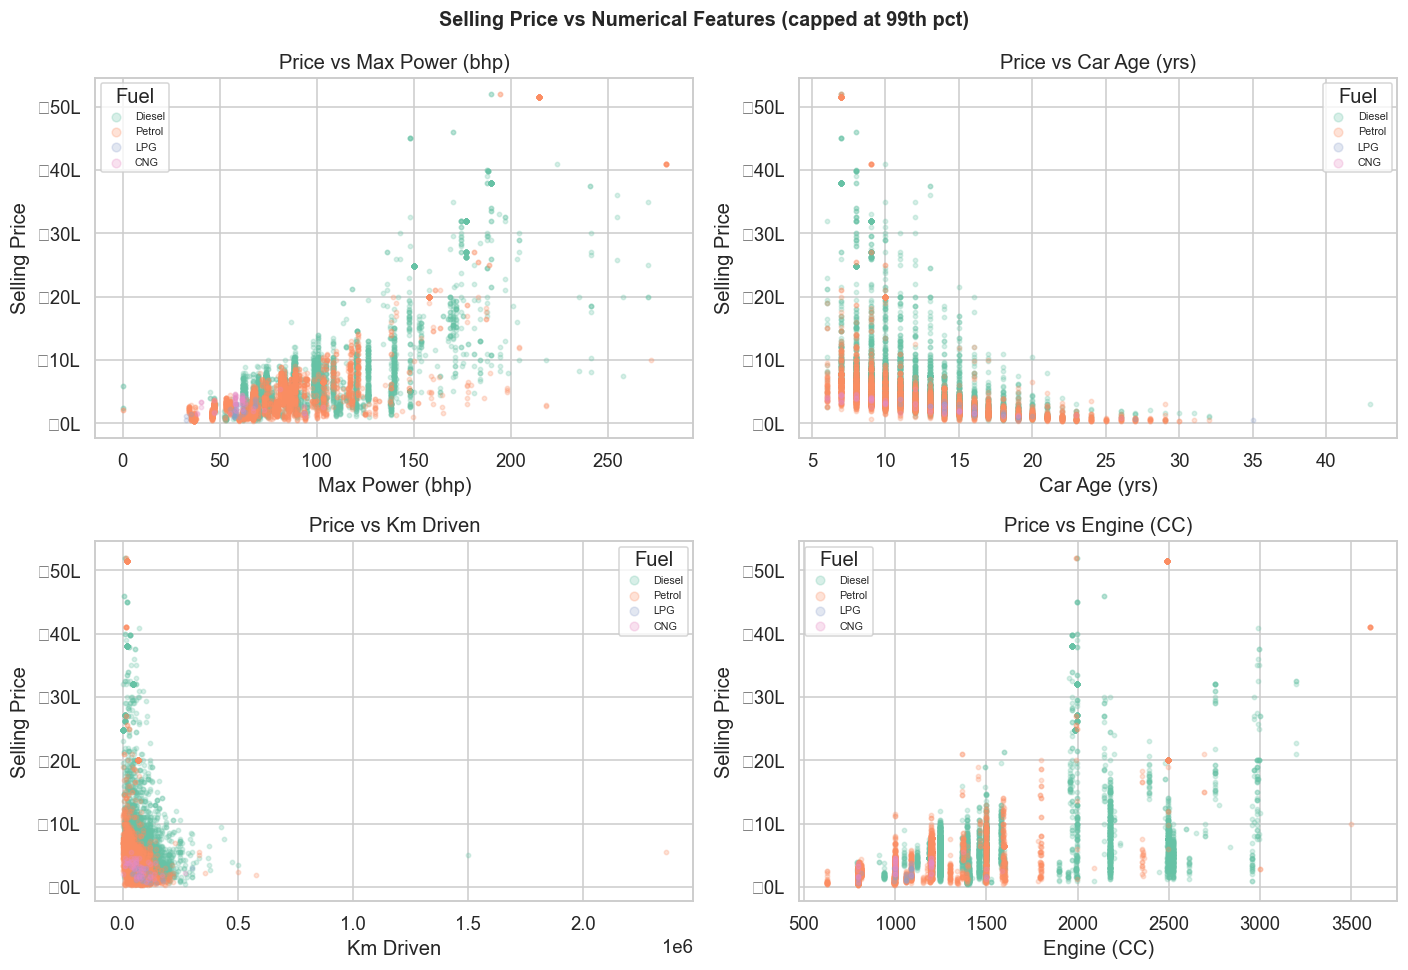

In [11]:
# Scatter: selling price vs max_power, car_age, km_driven, engine
scatter_cols = [
    ('max_power_num', 'Max Power (bhp)'),
    ('car_age',       'Car Age (yrs)'),
    ('km_driven',     'Km Driven'),
    ('engine',        'Engine (CC)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (col, lbl) in enumerate(scatter_cols):
    sub = df[['selling_price', col, 'fuel']].dropna()
    # cap price at 99th percentile for readability
    cap = sub['selling_price'].quantile(0.99)
    sub = sub[sub['selling_price'] <= cap]
    fuels = sub['fuel'].unique()
    palette = dict(zip(fuels, sns.color_palette('Set2', len(fuels))))
    for fuel in fuels:
        s = sub[sub['fuel'] == fuel]
        axes[i].scatter(s[col], s['selling_price'], alpha=0.25, s=8,
                        color=palette[fuel], label=fuel)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
    axes[i].set_xlabel(lbl)
    axes[i].set_ylabel('Selling Price')
    axes[i].set_title(f'Price vs {lbl}')
    axes[i].legend(title='Fuel', fontsize=7, markerscale=2)

plt.suptitle('Selling Price vs Numerical Features (capped at 99th pct)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

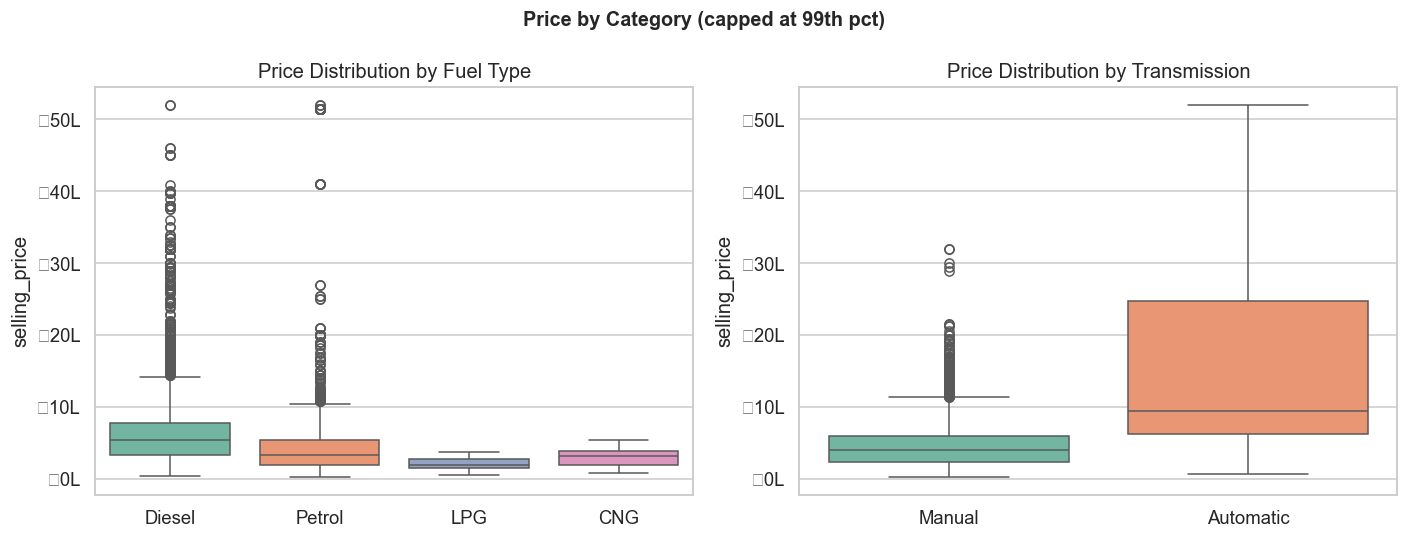

In [12]:
# Box plots: price by fuel and transmission
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cap = df['selling_price'].quantile(0.99)
sub = df[df['selling_price'] <= cap].copy()

sns.boxplot(data=sub, x='fuel', y='selling_price', ax=axes[0], palette='Set2')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].set_title('Price Distribution by Fuel Type')
axes[0].set_xlabel('')

sns.boxplot(data=sub, x='transmission', y='selling_price', ax=axes[1], palette='Set2')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[1].set_title('Price Distribution by Transmission')
axes[1].set_xlabel('')

plt.suptitle('Price by Category (capped at 99th pct)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

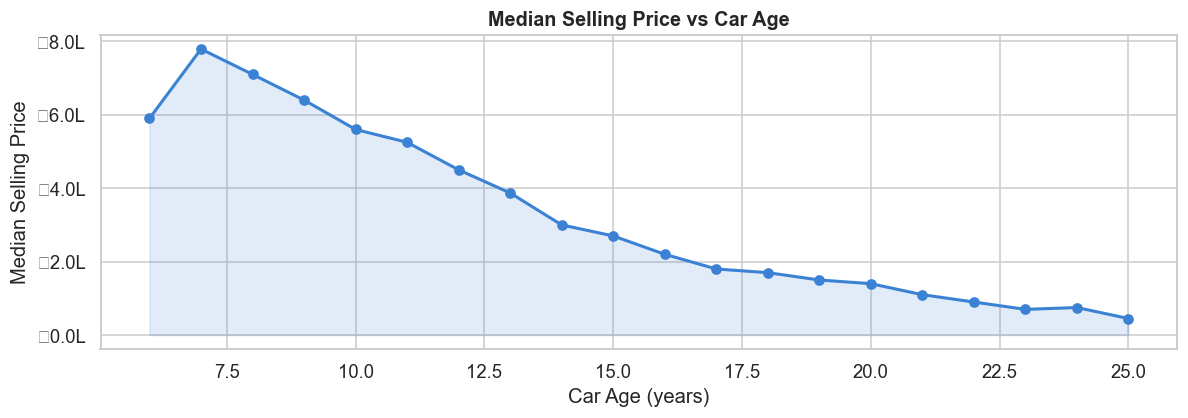

In [13]:
# Median price by car age
age_price = df.groupby('car_age')['selling_price'].median().reset_index()
age_price = age_price[age_price['car_age'] <= 25]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(age_price['car_age'], age_price['selling_price'], marker='o', color='#3b82d4', linewidth=2)
ax.fill_between(age_price['car_age'], age_price['selling_price'], alpha=0.15, color='#3b82d4')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L'))
ax.set_xlabel('Car Age (years)')
ax.set_ylabel('Median Selling Price')
ax.set_title('Median Selling Price vs Car Age', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Outlier Analysis

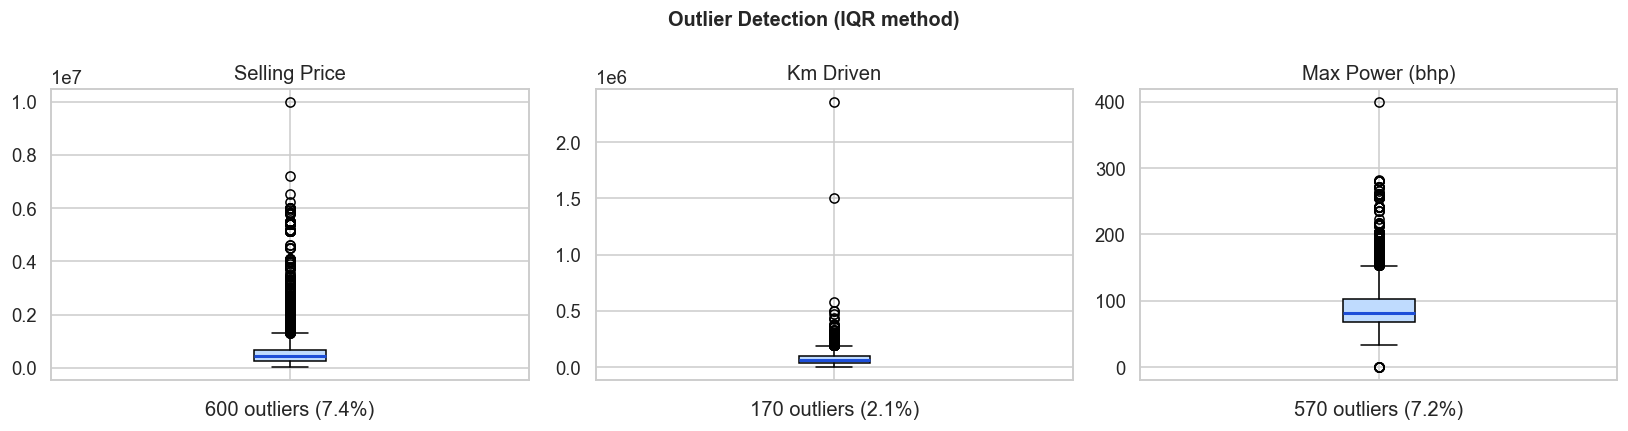

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, lbl) in zip(axes, [
    ('selling_price', 'Selling Price'),
    ('km_driven',     'Km Driven'),
    ('max_power_num', 'Max Power (bhp)'),
]):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#bfdbfe'),
               medianprops=dict(color='#1d4ed8', linewidth=2))
    ax.set_title(lbl)
    ax.set_xticklabels([])
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outliers = data[(data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)]
    ax.set_xlabel(f'{len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)')

plt.suptitle('Outlier Detection (IQR method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Top 10 most expensive cars
print('Top 10 most expensive listings:')
df_raw.nlargest(10, 'selling_price')[['name','year','selling_price','fuel','transmission','owner']]\
    .style.format({'selling_price': '₹{:,.0f}'})

Top 10 most expensive listings:


,name,year,selling_price,fuel,transmission,owner
170,Volvo XC90 T8 Excellence BSIV,2017,"₹10,000,000",Petrol,Automatic,First Owner
2938,BMW X7 xDrive 30d DPE,2020,"₹7,200,000",Diesel,Automatic,First Owner
4952,Audi A6 35 TFSI Matrix,2019,"₹6,523,000",Petrol,Automatic,Test Drive Car
4950,Audi A6 35 TFSI Matrix,2019,"₹6,223,000",Petrol,Automatic,Test Drive Car
136,Mercedes-Benz S-Class S 350 CDI,2017,"₹6,000,000",Diesel,Automatic,First Owner
1071,BMW 6 Series GT 630d Luxury Line,2018,"₹6,000,000",Diesel,Automatic,First Owner
4101,BMW 6 Series GT 630d Luxury Line,2018,"₹6,000,000",Diesel,Automatic,First Owner
4766,BMW 6 Series GT 630d Luxury Line,2018,"₹6,000,000",Diesel,Automatic,First Owner
5258,Mercedes-Benz S-Class S 350 CDI,2017,"₹6,000,000",Diesel,Automatic,First Owner
7713,Mercedes-Benz S-Class S 350 CDI,2017,"₹6,000,000",Diesel,Automatic,First Owner


---
## 9. Key Findings Summary

In [16]:
print('='*60)
print('  KEY FINDINGS')
print('='*60)
print(f'  Total records      : {len(df_raw):,}')
print(f'  Year range         : {df_raw["year"].min()} – {df_raw["year"].max()}')
print(f'  Price range        : ₹{df_raw["selling_price"].min():,.0f} – ₹{df_raw["selling_price"].max():,.0f}')
print(f'  Median price       : ₹{df_raw["selling_price"].median():,.0f}')
print()
print('  Most common fuel    :', df_raw['fuel'].mode()[0])
print('  Most common seller  :', df_raw['seller_type'].mode()[0])
print('  Most common trans   :', df_raw['transmission'].mode()[0])
print('  Most common owner   :', df_raw['owner'].mode()[0])
print()
print('  Columns with nulls  :', df_raw.isnull().sum()[df_raw.isnull().sum()>0].index.tolist())
print()
print('  Strongest predictors (from model feature importance):')
print('    1. max_power  — 72.4% importance')
print('    2. car_age    — 19.1% importance')
print('    3. km_driven  —  2.7% importance')
print()
print('  Model results (Random Forest best):')
print('    RMSE ₹1,41,976 | R² 0.9692')
print('='*60)

  KEY FINDINGS
  Total records      : 8,128
  Year range         : 1983 – 2020
  Price range        : ₹29,999 – ₹10,000,000
  Median price       : ₹450,000

  Most common fuel    : Diesel
  Most common seller  : Individual
  Most common trans   : Manual
  Most common owner   : First Owner

  Columns with nulls  : ['mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']

  Strongest predictors (from model feature importance):
    1. max_power  — 72.4% importance
    2. car_age    — 19.1% importance
    3. km_driven  —  2.7% importance

  Model results (Random Forest best):
    RMSE ₹1,41,976 | R² 0.9692
